<a href="https://colab.research.google.com/github/therokitoki/AA2_TP_Alsop-Hachen-Nemeth/blob/main/TP2_ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Practico N°2 AAII

Alumnos: Agustin Alsop, Rocio Hachen, Ulises Nemeth

## Ejercicio 1

### Descripción:
En este problema, se presenta un conjunto de datos que contiene clips de audio correspondientes a dígitos hablados del 0 al 9.

### Dataset:
https://www.tensorflow.org/datasets/catalog/spoken_digit

El dataset proporcionado incluye un total de 2500 clips de audio correspondientes a 5 locutores distintos, 50 clips por dígito por locutor.

### Objetivo:
Utilizando el dataset proporcionado, el objetivo es construir un modelo de clasificación utilizando redes neuronales que pueda inferir con precisión el dígito correspondiente dado un clip de audio. Se deben entrenar y evaluar modelos utilizando técnicas adecuadas de validación y métricas de evaluación de clasificación.

Se solicita entrenar dos modelos de distintas arquitecturas y comparar los resultados:
Modelo convolucional sobre los espectrogramas de los clips.
Modelo recurrente sobre los espectrogramas de los clips.

Ver https://colab.research.google.com/github/FCEIA-AAII/lab11/blob/master/lab11-a.ipynb como ejemplo de obtención de espectrogramas a partir de clips de audio.

### Entrega:
Código fuente de la solución implementada en Google Colab, que incluya:
- Análisis previo y preprocesamiento del set de datos.
- Definición y entrenamiento del modelo.
- Resultados de la evaluación de los modelos, incluyendo métricas de desempeño y visualizaciones relevantes.

Nota: el código debe estar debidamente documentado con comentarios explicativos para que el trabajo sea fácilmente comprensible para otros revisores.


# Preparación del entorno

In [183]:
!pip install -U tensorflow-datasets

## Librerias

In [184]:
import os
import pathlib
import time

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers
from tensorflow.keras import models
from IPython import display

import soundfile as sf
from collections import defaultdict
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

# Preparación del entorno

In [185]:
# Configurar para que TensorFlow utilice la GPU por defecto
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Configurar para que TensorFlow asigne memoria dinámicamente
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        # Especificar la GPU por defecto
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Manejar error
        print(e)

1 Physical GPUs, 1 Logical GPUs


# Descarga de dataset

In [186]:
# Cargar dataset
ds = tfds.load('spoken_digit', split='train', as_supervised=False)
data = list(tfds.as_numpy(ds))

#print(ds.info.features)

# Agrupar los dígitos por hablante
speaker_digits = defaultdict(set)

for ex in data:
    label = int(ex['label'])
    filename = ex['audio/filename'].decode()
    speaker = filename.split('_')[1]
    speaker_digits[speaker].add(label)
print(" \n \n ")

# Verificamos que cada locutor haya dicho todos los dígitos.
for speaker, digits in speaker_digits.items():
    missing = set(range(10)) - digits
    if missing:
        print(f"🔴 {speaker} dijo {sorted(digits)} (faltan: {sorted(missing)})")
    else:
        print(f"🟢 {speaker} dijo TODOS los dígitos")


 
 
 
🟢 nicolas dijo TODOS los dígitos
🟢 theo dijo TODOS los dígitos
🟢 yweweler dijo TODOS los dígitos
🟢 george dijo TODOS los dígitos
🟢 jackson dijo TODOS los dígitos


# Preparación de datos

In [187]:
# Crear estructura para almacenar audios por persona y clase
data = defaultdict(lambda: defaultdict(list))

for example in tfds.as_numpy(ds):
    audio = example['audio']
    label = int(example['label'])
    filename = example['audio/filename'].decode()  # ejemplo: '0_jackson_0.wav'
    speaker = filename.split('_')[1]

    data[speaker][label].append((filename, audio))

# Carpetas de salida
output_root = 'spoken_digit_split'
splits = ['train', 'val']
for split in splits:
    for label in range(10):
        path = os.path.join(output_root, split, str(label))
        os.makedirs(path, exist_ok=True)

# Dividir y guardar
for speaker, digits in data.items():
    for digit, files in digits.items():
        random.shuffle(files)
        n = len(files)
        split_idx = int(0.8 * n) # 80-20

        train_files = files[:split_idx]
        val_files = files[split_idx:]

        for split, split_files in zip(['train', 'val'], [train_files, val_files]):
            for filename, audio in split_files:
                audio = audio.astype(np.int16)  # Evitar error de tipo
                path = os.path.join(output_root, split, str(digit), f"{speaker}_{filename}")
                sf.write(path, audio, samplerate=8000, subtype='PCM_16')


Para que no haya sesgo con ningun dígito ni con ningun tipo de voz, queremos que tanto 'train' como 'val' contengan audios de cada persona diciendo cada dígito la misma cantidad de veces.

In [188]:
train_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/train',
    batch_size=64,
    output_sequence_length=8000,
)

val_ds = tf.keras.utils.audio_dataset_from_directory(
    directory='spoken_digit_split/val',
    batch_size=64,
    output_sequence_length=8000,
    shuffle=False
)

label_names = np.array(train_ds.class_names)
num_classes = len(label_names)

Found 2500 files belonging to 10 classes.
Found 1661 files belonging to 10 classes.


# Análisis exploratorio

In [189]:
train_ds.element_spec

(TensorSpec(shape=(None, 8000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [190]:
print(f"Número de clases: {num_classes}")
print("label names:", label_names)

Número de clases: 10
label names: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [191]:
for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000, 1)
(64,)


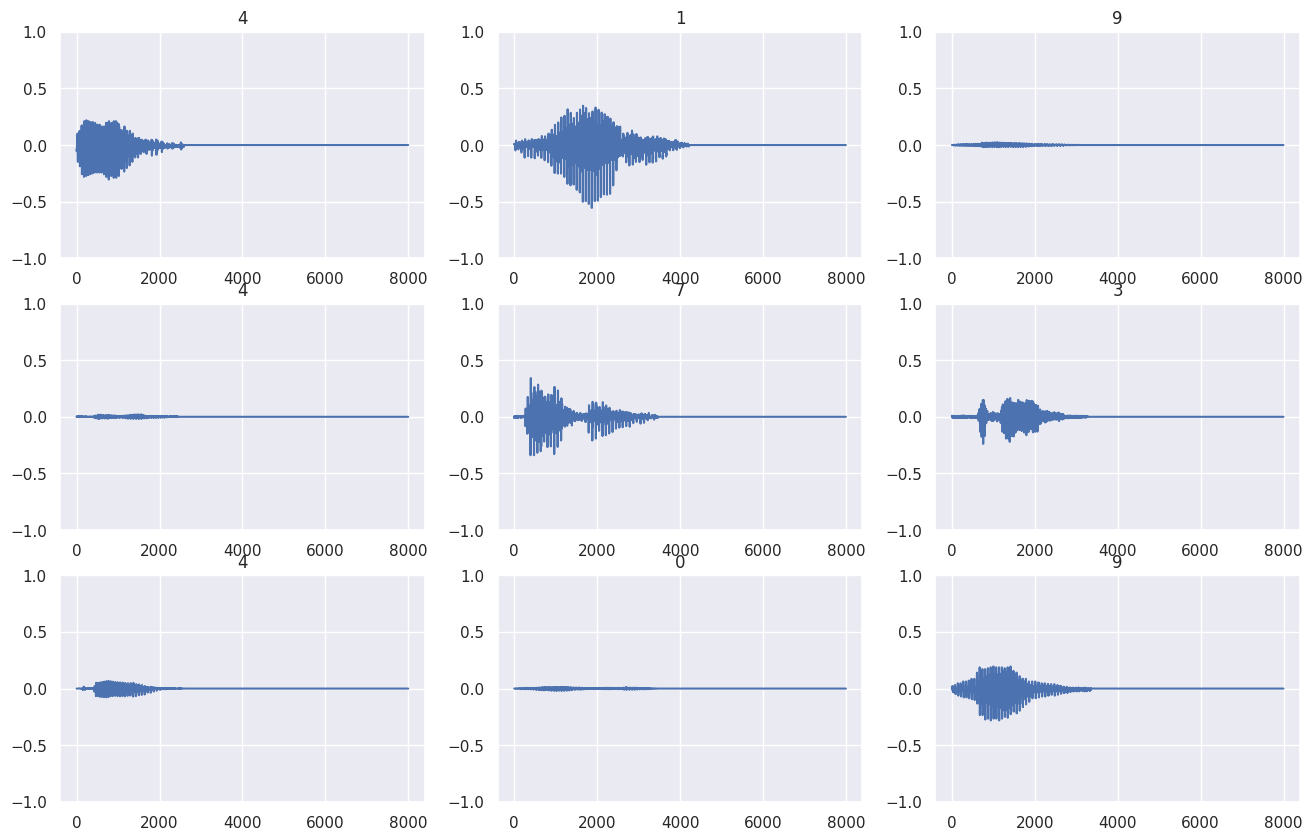

In [192]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  plt.plot(audio_signal)
  plt.title(label_names[example_labels[i]])
  #plt.yticks(np.arange(-7000, 0, 7000))
  plt.ylim([-1, 1])

Observamos que no siempre se utiliza toda la duracion del audio para decir el numero

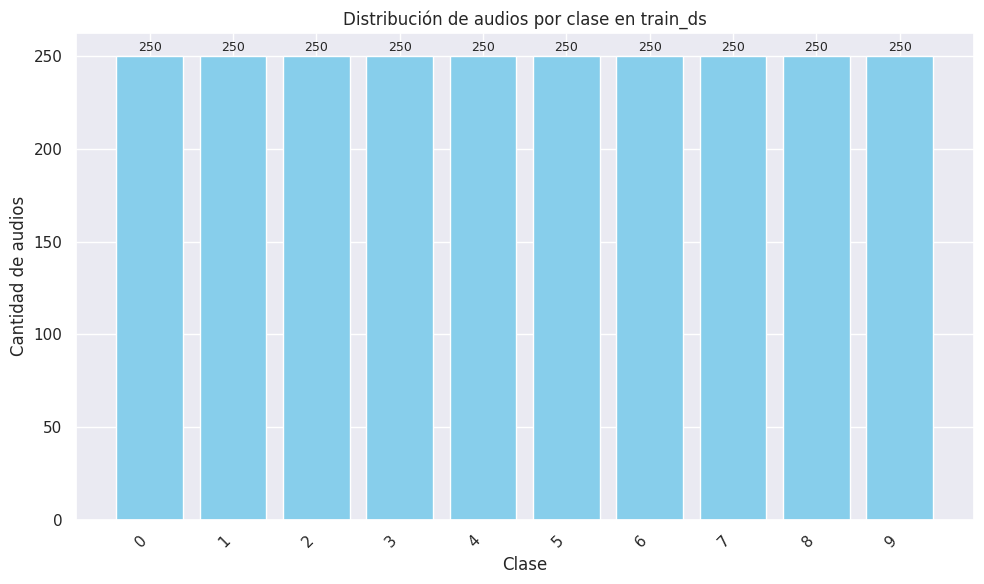

In [193]:
# Inicializamos contador
cant_clases = {name: 0 for name in train_ds.class_names}

# Recorremos el dataset
for audio, labels in train_ds:
    for label in labels.numpy():  # Convertimos a numpy para facilidad
        class_name = train_ds.class_names[label]
        cant_clases[class_name] += 1

# Visualización
plt.figure(figsize=(10, 6))
bars = plt.bar(cant_clases.keys(), cant_clases.values(), color='skyblue')
plt.xlabel("Clase")
plt.ylabel("Cantidad de audios")
plt.title("Distribución de audios por clase en train_ds")
plt.xticks(rotation=45, ha='right')

# Mostrar los valores arriba de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, str(int(yval)),
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


Podemos observar como el dataset esta totalmente balanceado

# Espectograma

Como el modelo espera un input de forma (batch, 8000), y nuestra data tiene forma (batch, 8000, 1), debemos quitar la última dimensión del tensor de audio que es de tamaño 1.

In [194]:
def squeeze(audio, labels):
  audio = tf.squeeze(audio, axis=-1)
  return audio, labels

train_ds = train_ds.map(squeeze, tf.data.AUTOTUNE)
val_ds = val_ds.map(squeeze, tf.data.AUTOTUNE)

for example_audio, example_labels in train_ds.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 8000)
(64,)


In [195]:
def get_spectrogram(waveform):
  # Convierte la onda de sonido a un espectograma
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)

  spectrogram = tf.abs(spectrogram)
  # Se agrega una dimension "canales" para que el espectograma pueda ser utilizado como input en capas convolucionales
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [196]:
for i in range(3):
  label = label_names[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)

  print('Etiqueta:', label)
  print('Forma de la onda:', waveform.shape)
  print('Forma del espectograma:', spectrogram.shape)
  print('Reproducción del audio:')
  display.display(display.Audio(waveform, rate=8000))

Etiqueta: 2
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


Etiqueta: 7
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


Etiqueta: 4
Forma de la onda: (8000,)
Forma del espectograma: (61, 129, 1)
Reproducción del audio:


In [197]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

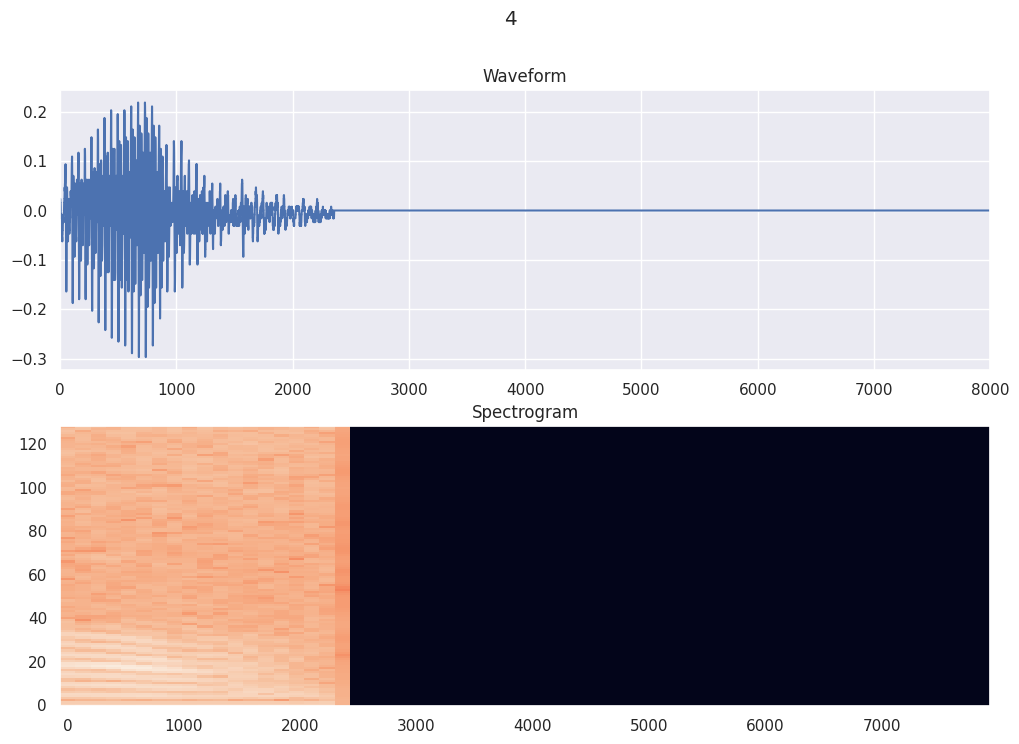

In [198]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 8000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

Si bien no podemos pretender obtener una comparativa entre el espectograma y el plot, se observa que la sección de audio sin frecuencia esta en violeta.

In [199]:
def make_spec_ds(ds):
  # Genera espectogramas para un dataset entero
  return ds.map(
      map_func=lambda audio,label: (get_spectrogram(audio), label),
      num_parallel_calls=tf.data.AUTOTUNE)

In [200]:
train_spectrogram_ds = make_spec_ds(train_ds)
val_spectrogram_ds = make_spec_ds(val_ds)

In [201]:
for example_spectrograms, example_spect_labels in train_spectrogram_ds.take(1):
  break

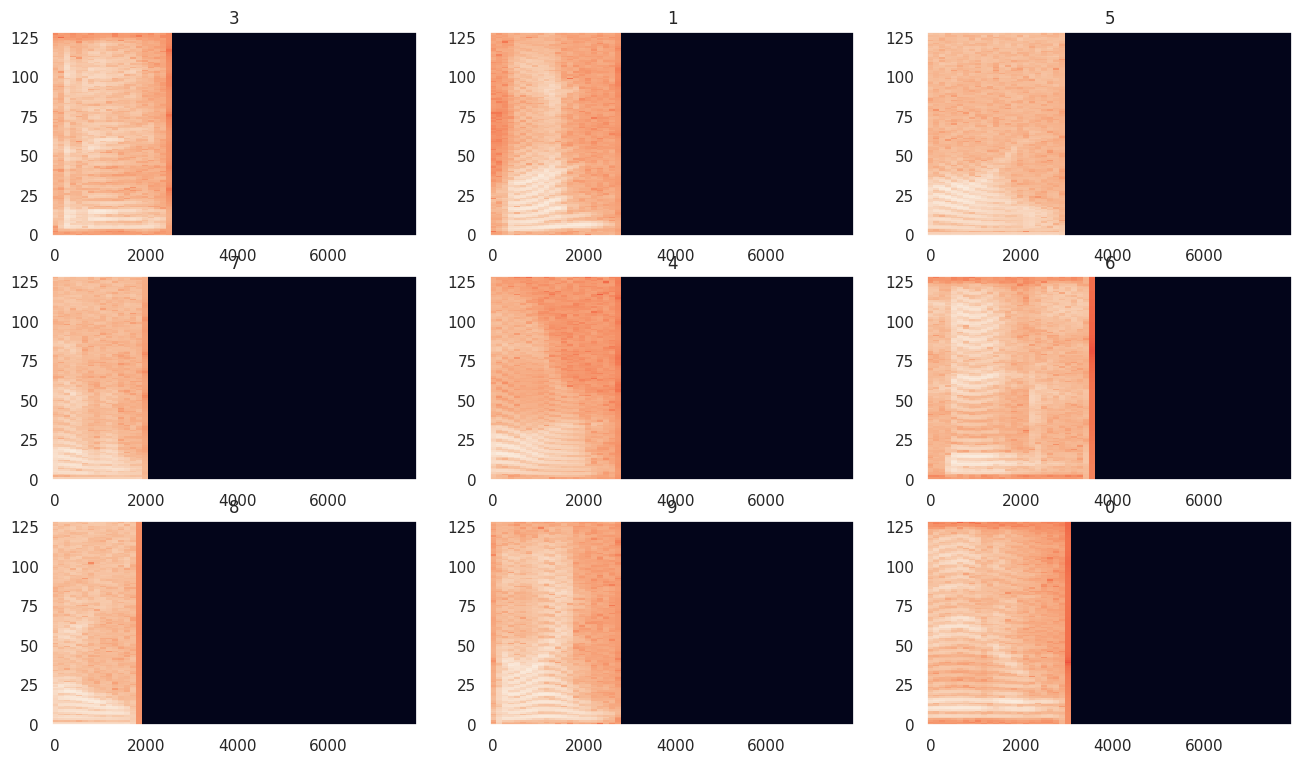

In [202]:
rows = 3
cols = 3
n = rows*cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 9))

for i in range(n):
    r = i // cols
    c = i % cols
    ax = axes[r][c]
    plot_spectrogram(example_spectrograms[i].numpy(), ax)
    ax.set_title(label_names[example_spect_labels[i].numpy()])

plt.show()

In [203]:
# Cache - guarda los datos en memoria lo que agiliza el tiempo de entrenamiento
# Shuffle - Baraja aleatoriamente los datos
train_spectrogram_ds = train_spectrogram_ds.cache().shuffle(10000).prefetch(tf.data.AUTOTUNE)
val_spectrogram_ds = val_spectrogram_ds.cache().prefetch(tf.data.AUTOTUNE)

# Modelos

## Modelo con Convulcionales

### Definición del modelo

In [204]:
example_spectrograms.shape

TensorShape([64, 61, 129, 1])

In [205]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Definimos la capa de normalización por separado para luego poder adaptarla.
norm_layer = layers.Normalization()
# Adapta el estado de la capa a los espectogramas
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model_cnn = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Resizing(32, 32),

    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model_cnn.summary()

Input shape: (61, 129, 1)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_4 (Resizing)           │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_8 (Normalization) │ (None, 32, 32, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,869 (6.20 MB)

 Trainable params: 1,625,866 (6.20 MB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [206]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [207]:
EPOCHS = 50
history_cnn = model_cnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.2898 - loss: 1.9956 - val_accuracy: 0.6713 - val_loss: 1.1413
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6129 - loss: 1.1895 - val_accuracy: 0.8206 - val_loss: 0.7150
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7300 - loss: 0.8274 - val_accuracy: 0.8880 - val_loss: 0.4965
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7995 - loss: 0.6467 - val_accuracy: 0.9229 - val_loss: 0.3419
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8506 - loss: 0.4819 - val_accuracy: 0.9392 - val_loss: 0.2811
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8832 - loss: 0.4138 - val_accuracy: 0.9561 - val_loss: 0.1972
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9003 - loss: 0.3249 - val_accuracy: 0.9759 - val_loss: 0.1537
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9158 - loss: 0.2873 - val_accuracy: 0.9783 -

Text(0.5, 1.0, 'Accuracy por época')

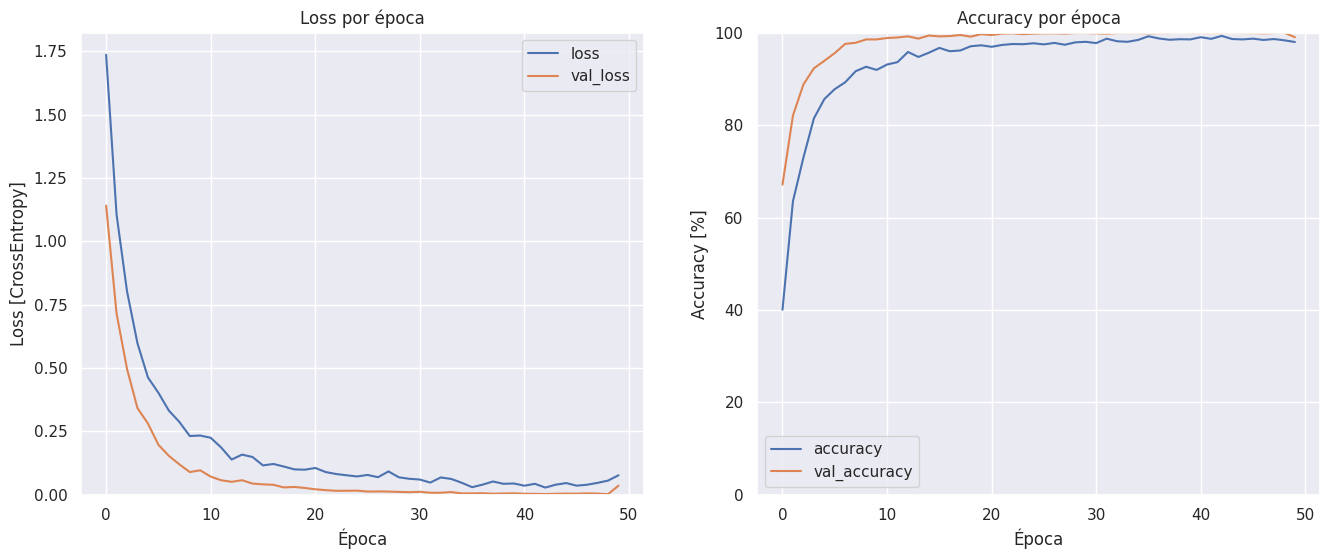

In [208]:
metrics = history_cnn.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history_cnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Época')
plt.ylabel('Loss [CrossEntropy]')
plt.title('Loss por época')

plt.subplot(1,2,2)
plt.plot(history_cnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Época')
plt.ylabel('Accuracy [%]')
plt.title('Accuracy por época')

### Predicción y matriz de confusión

In [209]:
y_pred = model_cnn.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


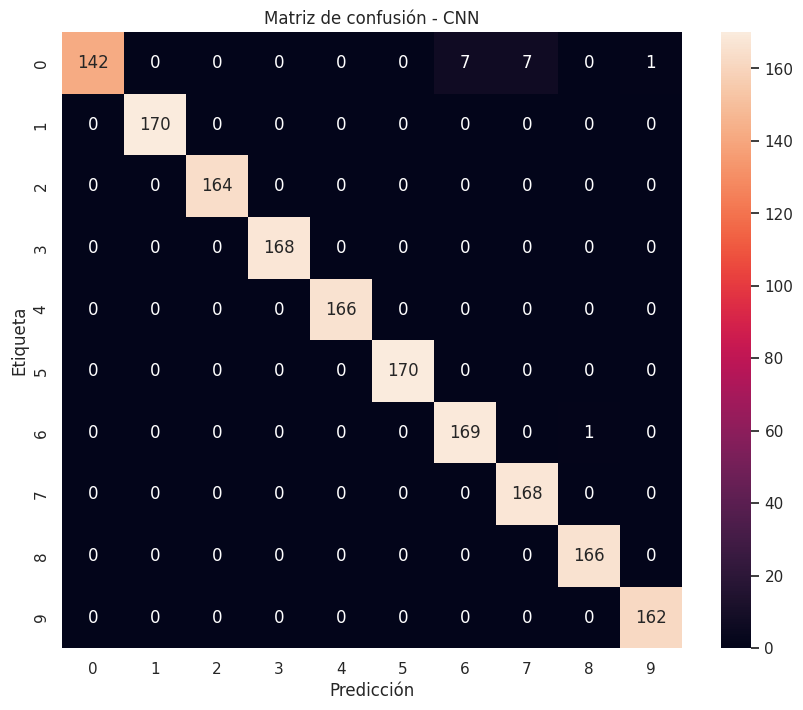

In [210]:
confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta')
plt.title('Matriz de confusión - CNN')
plt.show()

Podemos observar cómo la diagonal concentra la mayoría de las predicciones, demostrando el alto valor de `Accuracy` obtenido anteriormente (90%)

## Modelo con Recurrentes

### Definición del modelo

In [211]:
input_shape = example_spectrograms.shape[1:]  # (time_steps, freq_bins, 1)

print('Input shape:', input_shape)
num_labels = len(label_names)

# Normalización
norm_layer = layers.Normalization()
norm_layer.adapt(data=train_spectrogram_ds.map(lambda spec, label: spec))

model_rnn = models.Sequential([
    layers.Input(shape=input_shape),
    norm_layer,

    # Aplanamos el eje de frecuencia y dejamos el de tiempo para la RNN
    layers.Reshape((input_shape[0], input_shape[1])),

    # RNNs
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(64)),

    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_labels),
])

model_rnn.summary()

Input shape: (61, 129, 1)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_9 (Normalization) │ (None, 61, 129, 1)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 61, 129)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 61, 128)        │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,949 (843.55 KB)

 Trainable params: 215,946 (843.54 KB)

 Non-trainable params: 3 (16.00 B)

### Compilación

In [212]:
model_rnn.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

### Entrenamiento

In [213]:
EPOCHS = 50
history_rnn = model_rnn.fit(
    train_spectrogram_ds,
    validation_data=val_spectrogram_ds,
    epochs=EPOCHS,
    #callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.2369 - loss: 2.1301 - val_accuracy: 0.6069 - val_loss: 1.1881
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6202 - loss: 1.0711 - val_accuracy: 0.9019 - val_loss: 0.4383
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8340 - loss: 0.5257 - val_accuracy: 0.9308 - val_loss: 0.2174
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9254 - loss: 0.2600 - val_accuracy: 0.9290 - val_loss: 0.1928
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9153 - loss: 0.2431 - val_accuracy: 0.9831 - val_loss: 0.0654
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9688 - loss: 0.1299 - val_accuracy: 0.9783 - val_loss: 0.0678
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9805 - loss: 0.0743 - val_accuracy: 0.9801 - val_loss: 0.0682
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9822 - loss: 0.0723 - val_accuracy: 0.9922 - v

Text(0.5, 1.0, 'Accuracy por época')

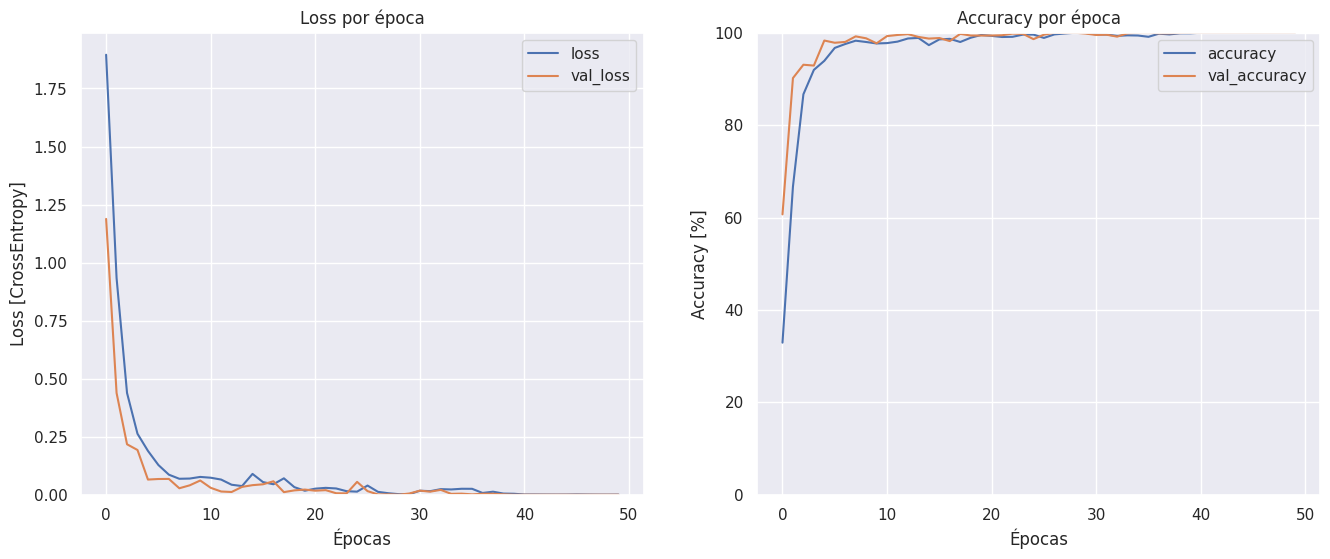

In [214]:
metrics = history_rnn.history
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(history_rnn.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.ylim([0, max(plt.ylim())])
plt.xlabel('Épocas')
plt.ylabel('Loss [CrossEntropy]')
plt.title('Loss por época')

plt.subplot(1,2,2)
plt.plot(history_rnn.epoch, 100*np.array(metrics['accuracy']), 100*np.array(metrics['val_accuracy']))
plt.legend(['accuracy', 'val_accuracy'])
plt.ylim([0, 100])
plt.xlabel('Épocas')
plt.ylabel('Accuracy [%]')
plt.title('Accuracy por época')

Observamos cómo los gráficos convergen alrededor de las 10 épocas.

### Predicción y matriz de confusión

In [215]:
y_pred = model_rnn.predict(val_spectrogram_ds)
y_pred = tf.argmax(y_pred, axis=1)
y_true = tf.concat(list(val_spectrogram_ds.map(lambda s,lab: lab)), axis=0)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


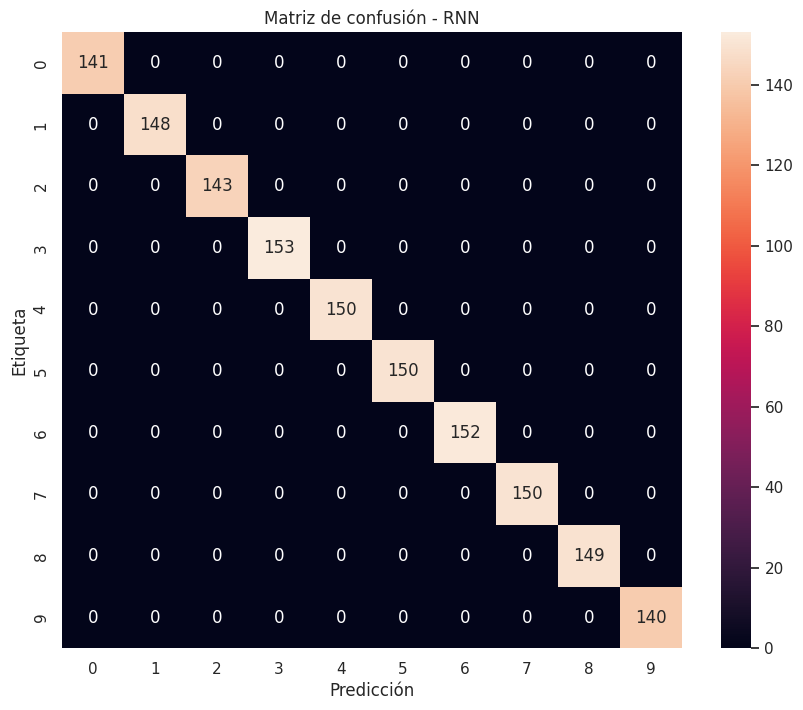

In [180]:

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=label_names,
            yticklabels=label_names,
            annot=True, fmt='g')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta')
plt.title('Matriz de confusión - RNN')
plt.show()

En la matriz de confusión podemos observar que obtuvimos una predicción perfecta

#Conclusiones

Comparar por accuracy que seran lo mismo por ende miramos los parametros y el tiempo de inferencia.

Falta

- Conclusiones
- Completar readme
- Comentar los graficos saludos
- Verificar el EDA

In [216]:
model_list = [model_cnn, model_rnn]
model_names = ['CNN', 'RNN']

results = []

for model, name in zip(model_list, model_names):
    # Evaluar accuracy en val
    loss, acc = model.evaluate(val_spectrogram_ds, verbose=0)

    # Medir tiempo de inferencia con un batch
    for spectrograms, labels in val_spectrogram_ds.take(1):
        start_time = time.perf_counter()
        predictions = model(spectrograms, training=False)
        end_time = time.perf_counter()
        inference_time = end_time - start_time
        avg_time_per_sample = inference_time / spectrograms.shape[0]

        num_params = model.count_params()

        results.append({
            'Modelo': name,
            'Nro Parameteros': num_params,
            'Tiempo de inferencia (batch)': inference_time,
            'Tiempo de inferencia (unidad)': avg_time_per_sample,
            'Accuracy': acc
        })

df_results = pd.DataFrame(results)

In [217]:
df_results

,Modelo,Nro Parameteros,Tiempo de inferencia (batch),Tiempo de inferencia (unidad),Accuracy
0,CNN,1625869,0.042391,0.000662,0.990367
1,RNN,215949,0.164525,0.002571,1.000000


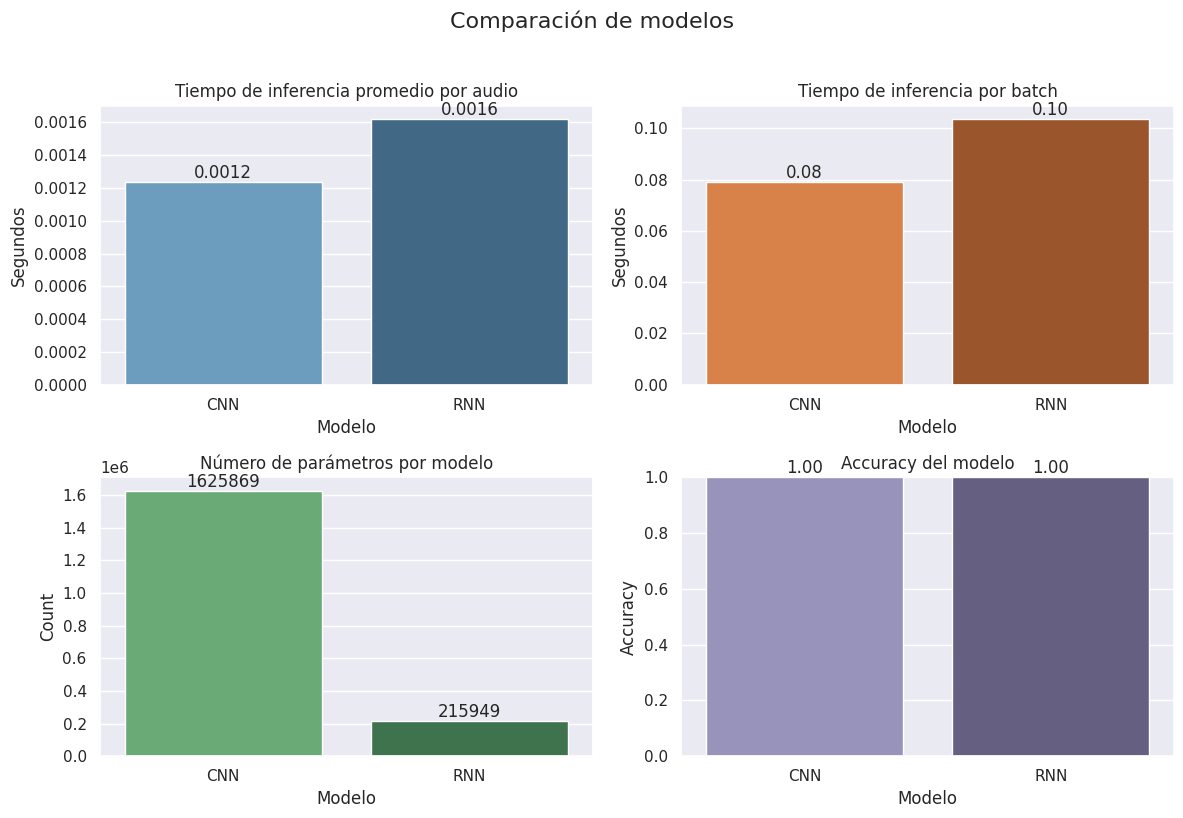

In [182]:
plt.figure(figsize=(12, 8))

plt.suptitle('Comparación de modelos', fontsize=16, y=1.02)  # Título general arriba

# Tiempo de inferencia (unidad)
plt.subplot(2, 2, 1)
ax1 = sns.barplot(data=df_results, x="Modelo", y="Tiempo de inferencia (unidad)", hue="Modelo", palette="Blues_d", legend=False)
plt.title("Tiempo de inferencia promedio por audio")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
for p in ax1.patches:
    height = p.get_height()
    ax1.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.4f}', ha="center", va="bottom")

# Tiempo de inferencia (batch)
plt.subplot(2, 2, 2)
ax2 = sns.barplot(data=df_results, x="Modelo", y="Tiempo de inferencia (batch)", hue="Modelo", palette="Oranges_d", legend=False)
plt.title("Tiempo de inferencia por batch")
plt.ylabel("Segundos")
plt.xlabel("Modelo")
for p in ax2.patches:
    height = p.get_height()
    ax2.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.2f}', ha="center", va="bottom")

# Nro. Parameteros
plt.subplot(2, 2, 3)
ax3 = sns.barplot(data=df_results, x="Modelo", y="Nro Parameteros", hue="Modelo", palette="Greens_d", legend=False)
plt.title("Número de parámetros por modelo")
plt.ylabel("Count")
plt.xlabel("Modelo")
for p in ax3.patches:
    height = p.get_height()
    ax3.text(p.get_x() + p.get_width() / 2., height,
             f'{int(height)}', ha="center", va="bottom")

# Accuracy
plt.subplot(2, 2, 4)
ax4 = sns.barplot(data=df_results, x="Modelo", y="Accuracy", hue="Modelo", palette="Purples_d", legend=False)
plt.title("Accuracy del modelo")
plt.ylabel("Accuracy")
plt.xlabel("Modelo")
plt.ylim(0, 1.0)
for p in ax4.patches:
    height = p.get_height()
    ax4.text(p.get_x() + p.get_width() / 2., height,
             f'{height:.2f}', ha="center", va="bottom")

plt.tight_layout()
plt.show()

Ambos modelos se destacan por su accuracy sobresaliente (98-99%), por lo que lo que definirá el "mejor modelo" serán las condiciones de trabajo que tengamos a disposición.

Si necesitamos un modelo que realice inferencias continuas y rápidas, el CNN será una mejor opción, ya que destaca sobre la RNN en velocidad de inferencia. Sin embargo, es un modelo mucho más grande, por lo que si queremos correrlo en dispositivos muy limitados, la RNN puede ser una mejor alternativa.